### Zero Shot Transfer- train i validate na starite podatoci i test na novite podatoci

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import glob
from tensorflow import keras
import os, glob, random

In [2]:

model = keras.models.load_model(r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\base_old_model.keras")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 200, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,701 (1.85 MB)

 Trainable params: 161,601 (631.25 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 323,204 (1.23 MB)

In [4]:
rootNoviPodatoci = r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\NASHITE PODATOCI"
subjectsNoviPodatoci = [d for d in os.listdir(rootNoviPodatoci) if os.path.isdir(os.path.join(rootNoviPodatoci, d))]

EXCLUDE = {"Teodora", "Sandra"} #bidejkji se povtoruvaat

label_col   = "Annotations"
subject_col = "subject"
time_col    = "Software Timestamp" 

FEATURE_COLS = [
    "Accelerometer/Raw.X",
    "Accelerometer/Raw.Y",
    "Gyroscope/Raw.X",
    "Gyroscope/Raw.Y",
    "RotationVector/Raw.X",
    "RotationVector/Raw.Y",
    "Nav/Raw.X[LeftTemple]",
    "Nav/Raw.Y[LeftTemple]",
    "Prox/Raw[LeftTemple]",
    "Nav/IQ[LeftTemple]",
    # "Nav/Shutter[LeftTemple]",
    # "Nav/FrameAvg[LeftTemple]",
]

RENAME_MAP_REVERSE = {
    "Accelerometer X": "Accelerometer/Raw.X",
    "Accelerometer Y": "Accelerometer/Raw.Y",

    "Gyroscope X": "Gyroscope/Raw.X",
    "Gyroscope Y": "Gyroscope/Raw.Y",

    "Rotation Vector X": "RotationVector/Raw.X",
    "Rotation Vector Y": "RotationVector/Raw.Y",

    "Navigation Right Temple X": "Nav/Raw.X[LeftTemple]",
    "Navigation Right Temple Y": "Nav/Raw.Y[LeftTemple]",
    "Proximity Right Temple": "Prox/Raw[LeftTemple]",
    "Navigation Right Temple IQ": "Nav/IQ[LeftTemple]",
    # "Navigation Right Temple Shutter": "Nav/Shutter[LeftTemple]",
    # "Navigation Right Temple Frame Avg": "Nav/FrameAvg[LeftTemple]",
}

WINDOW_SAMPLES = 200
STEP_SAMPLES   = 25
LABEL_STRATEGY = "majority"


In [ ]:
def make_windows_from_dfs(
    dfs,
    label_col,
    feature_cols,
    window_samples=150,
    step_samples=25,
    label_strategy="majority",
    subject_col="subject",
    time_col=None,
):
    
    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]

    X_list, y_list = [], []

    for df in dfs:
        
        if time_col and time_col in df.columns:
            df = df.sort_values([subject_col, time_col])

        
        missing = [c for c in feature_cols if c not in df.columns]
        if missing:
            
            continue

        X_raw = df[feature_cols].to_numpy(dtype=np.float32)
        y_raw = df[label_col].to_numpy(dtype=np.int32)

        n = len(X_raw)
        if n < window_samples:
            continue

        for start in range(0, n - window_samples + 1, step_samples):
            end = start + window_samples
            Xw = X_raw[start:end]
            y_seg = y_raw[start:end]

            if label_strategy == "last":
                yw = int(y_seg[-1])
            else:  # majority
                vals, counts = np.unique(y_seg, return_counts=True)
                yw = int(vals[np.argmax(counts)])

            X_list.append(Xw)
            y_list.append(yw)

    if len(X_list) == 0:
        return np.empty((0, window_samples, len(feature_cols)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.int32)


In [ ]:
subjectsNoviPodatoci = [
    d for d in os.listdir(rootNoviPodatoci)
    if os.path.isdir(os.path.join(rootNoviPodatoci, d))
]

EXCLUDE = {"Teodora", "Sandra"}  
test_subjects = [s for s in subjectsNoviPodatoci if s not in EXCLUDE]

print("New TEST subjects:", len(test_subjects))
print("First 10:", sorted(test_subjects)[:10])


New TEST subjects: 30
First 10: ['AleksandraK', 'AnaI', 'AndrejCh', 'AndrejJ', 'AngelaK', 'DavidN', 'ElenaA', 'HristijanD', 'IrinaP', 'IvaI']


In [ ]:
# најди цсв по субјецт
subject_csv_new = {}
for s in test_subjects:
    subj_dir = os.path.join(rootNoviPodatoci, s)
    csvs = glob.glob(os.path.join(subj_dir, "*eating_processed.csv"))
    if len(csvs) == 0:
        print(f"NO eating_processed for {s}")
    else:
        subject_csv_new[s] = csvs[0]

print("Found csvs for:", len(subject_csv_new), "subjects")

cols_to_drop = [
    "Accelerometer Z",
    "Gyroscope Z",
    "Rotation Vector Z",
    "Rotation Vector W",
    "Magnetometer X",
    "Magnetometer Y",
    "Magnetometer Z",
    "Pressure",
    "Software Timestamp",
    "Hardware Timestamp",
]

def load_subject_df_new(subject):
    df = pd.read_csv(subject_csv_new[subject])
    df[subject_col] = subject

    df = df.rename(columns=RENAME_MAP_REVERSE)

    df = df.drop(columns=cols_to_drop, errors="ignore")

    # da gi zadrzi samo FEATURE_COLS + labels + subject + time ako ima
    keep = FEATURE_COLS + [label_col, subject_col]
    if time_col in df.columns:
        keep = keep + [time_col]

    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[{subject}] Missing features after rename: {missing}")

    df = df[keep]
    return df

# load all
test_dfs_new = []
for s in sorted(subject_csv_new.keys()):
    try:
        test_dfs_new.append(load_subject_df_new(s))
    except Exception as e:
        print("SKIP", s, "->", e)

print("Loaded new dfs:", len(test_dfs_new))
print("Example shape:", test_dfs_new[0].shape)
print("Example columns:", test_dfs_new[0].columns.tolist())


Found csvs for: 30 subjects
Loaded new dfs: 30
Example shape: (30001, 12)
Example columns: ['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X', 'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y', 'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]', 'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]', 'Annotations', 'subject']


In [8]:
X_test, y_test = make_windows_from_dfs(
    test_dfs_new,
    label_col=label_col,
    feature_cols=FEATURE_COLS,
    window_samples=WINDOW_SAMPLES,
    step_samples=STEP_SAMPLES,
    label_strategy=LABEL_STRATEGY,
    subject_col=subject_col,
    time_col=time_col  
)

print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("Test label bincount:", np.bincount(y_test) if len(y_test) else "EMPTY", "ratio:", float(y_test.mean()) if len(y_test) else "n/a")


X_test: (36619, 200, 10) y_test: (36619,)
Test label bincount: [14869 21750] ratio: 0.5939539583276441


In [9]:
print(test_dfs_new[0].columns)
print("n_features =", len(test_dfs_new[0].columns))

Index(['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X',
       'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y',
       'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]',
       'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]', 'Annotations', 'subject'],
      dtype='object')
n_features = 12


In [10]:
test_subjects  = test_dfs_new

print("TEST:",  len(test_subjects), test_subjects)

TEST: 30 [       Accelerometer/Raw.X  Accelerometer/Raw.Y  Gyroscope/Raw.X  \
0                 0.167651            -9.730965        26.768293   
1                -0.002395            -9.553733        20.487804   
2                -0.162861            -9.616003        18.841463   
3                -0.182021            -9.551338        20.853659   
4                -0.172441            -9.611214        21.402440   
...                    ...                  ...              ...   
29996             0.673001            -9.766890         0.731707   
29997             0.730481           -10.001601        -1.463415   
29998             0.725691           -10.399175        -4.024390   
29999             0.706531           -10.552456        -5.853659   
30000             0.742456           -10.336905        -6.890244   

       Gyroscope/Raw.Y  RotationVector/Raw.X  RotationVector/Raw.Y  \
0           -71.280490                 -2894                  9864   
1           -71.524390           

In [12]:
sc = np.load(r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\base_old_scaler.npz")
mean = sc["mean"]
std  = sc["std"]

if mean.ndim == 1:
    mean = mean.reshape(1,1,-1)
    std  = std.reshape(1,1,-1)

X_test_all_z = (X_test - mean) / std
print("scaled:", X_test_all_z.shape)

scaled: (36619, 200, 10)


In [13]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
y_prob = model.predict(X_test_all_z, batch_size=256).ravel()

thr = 0.5  
y_pred = (y_prob >= 0.8876848).astype(int)

print("pred 1 ratio:", y_pred.mean())

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
pred 1 ratio: 0.48605914962178104
[[12877  1992]
 [ 5943 15807]]
              precision    recall  f1-score   support

           0     0.6842    0.8660    0.7645     14869
           1     0.8881    0.7268    0.7994     21750

    accuracy                         0.7833     36619
   macro avg     0.7862    0.7964    0.7819     36619
weighted avg     0.8053    0.7833    0.7852     36619



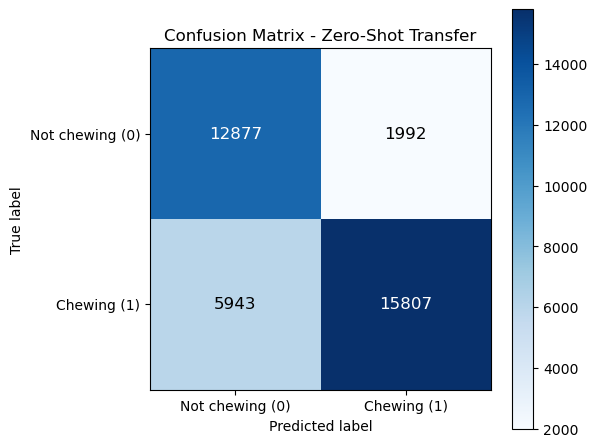

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix - Zero-Shot Transfer")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

classes = ["Not chewing (0)", "Chewing (1)"]
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thr_list = roc_curve(y_test, y_prob)
best_thr = thr_list[(tpr - fpr).argmax()]
print("best_thr:", best_thr)


best_thr: 0.8876848


best_thr: 0.8876848


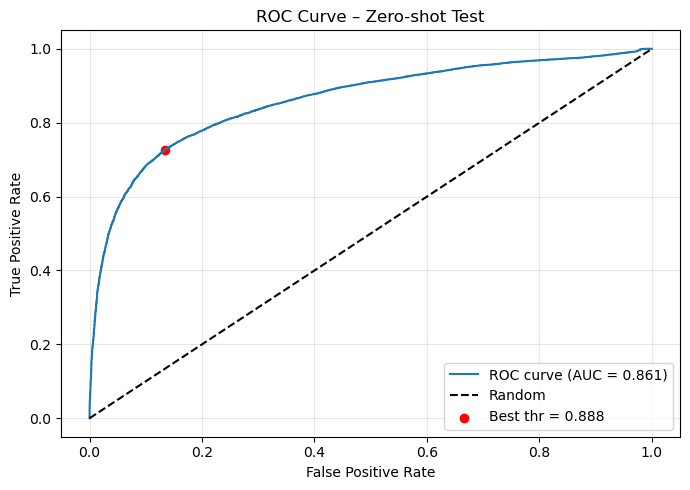

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thr_list = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

best_idx = np.argmax(tpr - fpr)
best_thr = thr_list[best_idx]

print("best_thr:", best_thr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

# означи best threshold
plt.scatter(
    fpr[best_idx],
    tpr[best_idx],
    color="red",
    label=f"Best thr = {best_thr:.3f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Zero-shot Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


-Vo 86% od slucaevite modelot kje mu dade povisok score na vistinski 1, otkolku na 0.